In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr 
import tams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
import seaborn as sns
import os
import numpy as np
import analysis_functions as af2
import pickle as pkl

from joblib import Parallel, delayed
from scipy.stats import gaussian_kde
from pathlib import Path


import warnings
warnings.filterwarnings('ignore')

* Extracted from tams_predata.ipynb

* In order to take care of some nan values found in ctt, we're going to crop the lon coordinates as they are the main problem (see nan_check for more information)

# Resolutions (from higher to lower)

- Original _Tb_ = ?

(a) 0.1x0.1 

(b) 0.25x0.25 

- Original _Tp_ (_pr_) = 0.1x0.1 _note_: Same as (a) from _Tb_

(a) 0.25x0.25 


In [ ]:
tp, tbI = af2.open_pr_tp("./TFM/observations", "precipitation_IMERG_1999_WA_0.25x0.25.nc", "tb_merg_1999_WA_0.25x0.25.nc")
ds = xr.Dataset({'tb': tbI, 'tp': tp})
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 5856, lon: 359, lat: 119)
Coordinates:
  * time     (time) datetime64[ns] 47kB 1999-06-01 ... 1999-09-30T23:30:00
  * lon      (lon) float64 3kB -39.75 -39.5 -39.25 -39.0 ... 49.25 49.5 49.75
  * lat      (lat) float64 952B 0.25 0.5 0.75 1.0 1.25 ... 29.0 29.25 29.5 29.75
Data variables:
    tb       (time, lat, lon) float32 1GB dask.array<chunksize=(95, 119, 359), meta=np.ndarray>
    tp       (time, lat, lon) float32 1GB dask.array<chunksize=(96, 119, 359), meta=np.ndarray>

- Let's fix the exact timestamp where we have a row full of nans. I'll skip them, returning an empty GeoDataFrame for that moment. 

In [ ]:
ds = xr.Dataset({'tb': tbI, 'tp': tp})

cesI, _ = tams.identify(tbI.compute(), parallel=True);

cesI_all = af2.Parallel_nan_ds(cesI, ds)

In [ ]:
cesI_c = cesI_all.copy()
print(len(cesI_all), len(cesI_c))
print(True if cesI_all == cesI_c else False)

- Do tracking

In [ ]:
proj = -10
times = tbI.time.values.tolist()

ces_T = tams.track(cesI, times, u_projection=-10) #Change cesI to cesI_c to test

In [ ]:
ce_clasI = tams.classify(ces_T)

## Other Year

In [ ]:
root = "./TFM/observations"

pr_pre = "precipitation_IMERG_2024_WA" # This can be changed to match the data and resolution.
tp_file = f"{pr_pre}_0.25x0.25.nc"

temp_pre = "tb_merg_2024_WA" # This can be changed to match the data and resolution.
tb_file = f"{temp_pre}_0.25x0.25.nc"

tp, tbI = af2.open_pr_tp(root, tp_file, tb_file)
ds = xr.Dataset({'tb': tbI, 'tp': tp})

In [ ]:
timeI = tbI.time.values.tolist()

cesI, _ = tams.identify(tbI.compute(), parallel=True);

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   22.0s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   22.7s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   24.7s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   28.4s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   30.8s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:   33.9s
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:   37.8s
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:   39.3s
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:   

In [10]:
cesI_all = af2.Parallel_ds(cesI, ds)

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-2)]: Done  18 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-2)]: Done  27 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-2)]: Done  47 tasks      | elapsed:   30.2s
[Parallel(n_jobs=-2)]: Done  58 tasks      | elapsed:   36.7s
[Parallel(n_jobs=-2)]: Done  71 tasks      | elapsed:   43.7s
[Parallel(n_jobs=-2)]: Done  84 tasks      | elapsed:   48.6s
[Parallel(n_jobs=-2)]: Done  99 tasks      | elapsed:   57.1s
[Parallel(n_jobs=-2)]: Done 114 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-2)]: Done 131 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-2)]: Done 148 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-2)]: Done 167 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-2)]: Done 186 tasks      | elapsed:  1

In [11]:
cesI_c = cesI_all.copy()
print(type(cesI_c))

<class 'list'>


In [12]:
af2.save_parquet(cesI_c, "tams_2024_01")

In [13]:
ces_par = af2.list_from_parquet("./parquet_sets/tams_2024_01.parquet", len(tbI.time))
proj = -10
times = tbI.time.values.tolist()



In [14]:
ces_T = tams.track(ces_par, times, u_projection=-10)

In [15]:
ce_clasI = tams.classify(ces_T)

- Test pkl

In [ ]:
def load_classified(filename: str, root: str = "./TFM/pkl_sets") -> gpd.GeoDataFrame:
    """Load a classified GeoDataFrame from a pickle file."""
    filepath = os.path.join(root, f"{filename}.pkl")
    with open(filepath, "rb") as f:
        return pkl.load(f)

ce_claI_p = load_classified("cesC_2024_01")

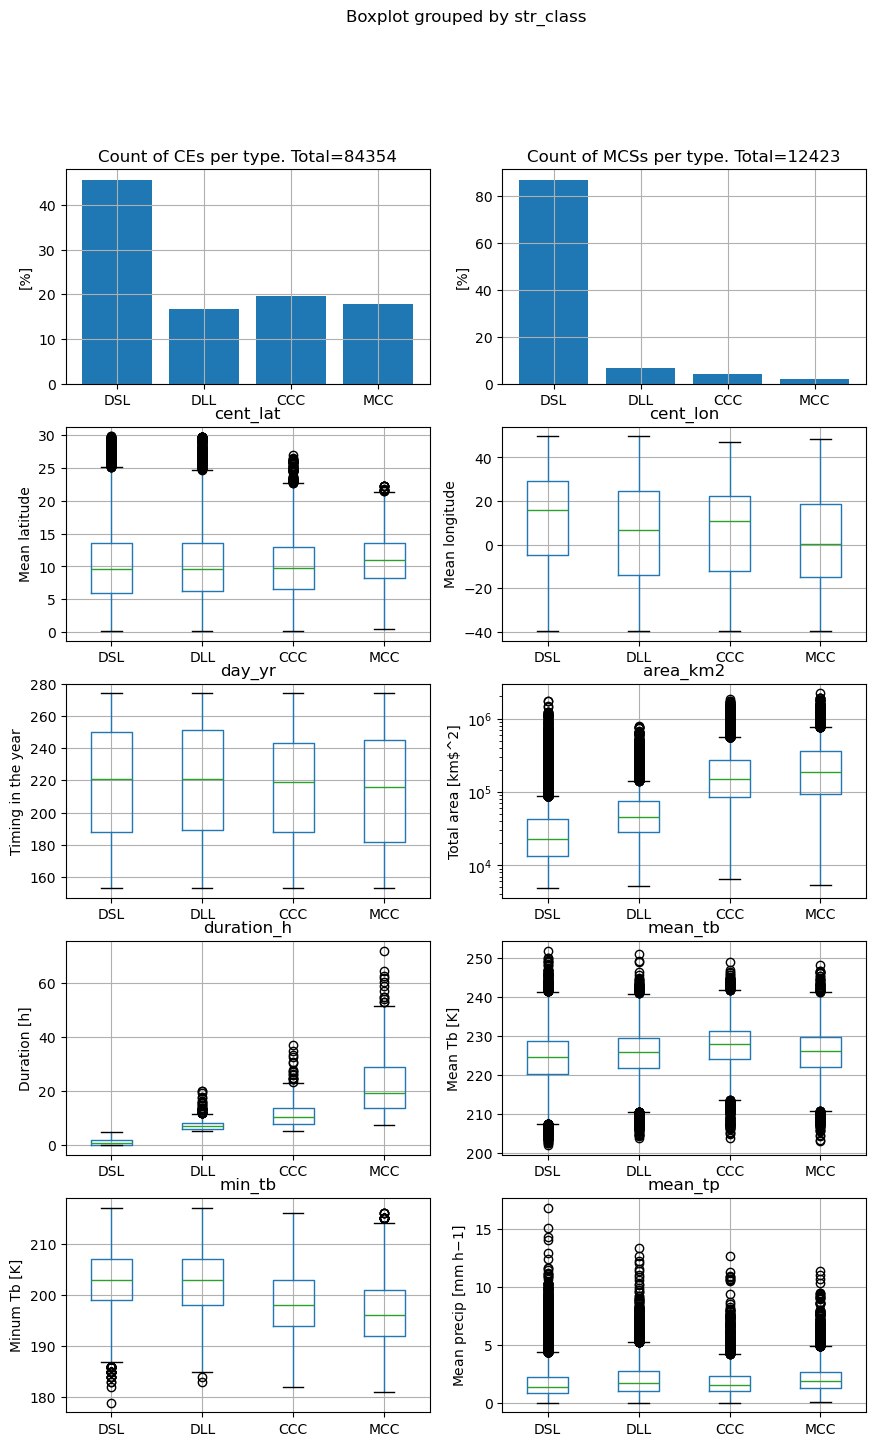

In [8]:
af2.dibujoMCS(ce_claI_p)

- Seasonal_latlon

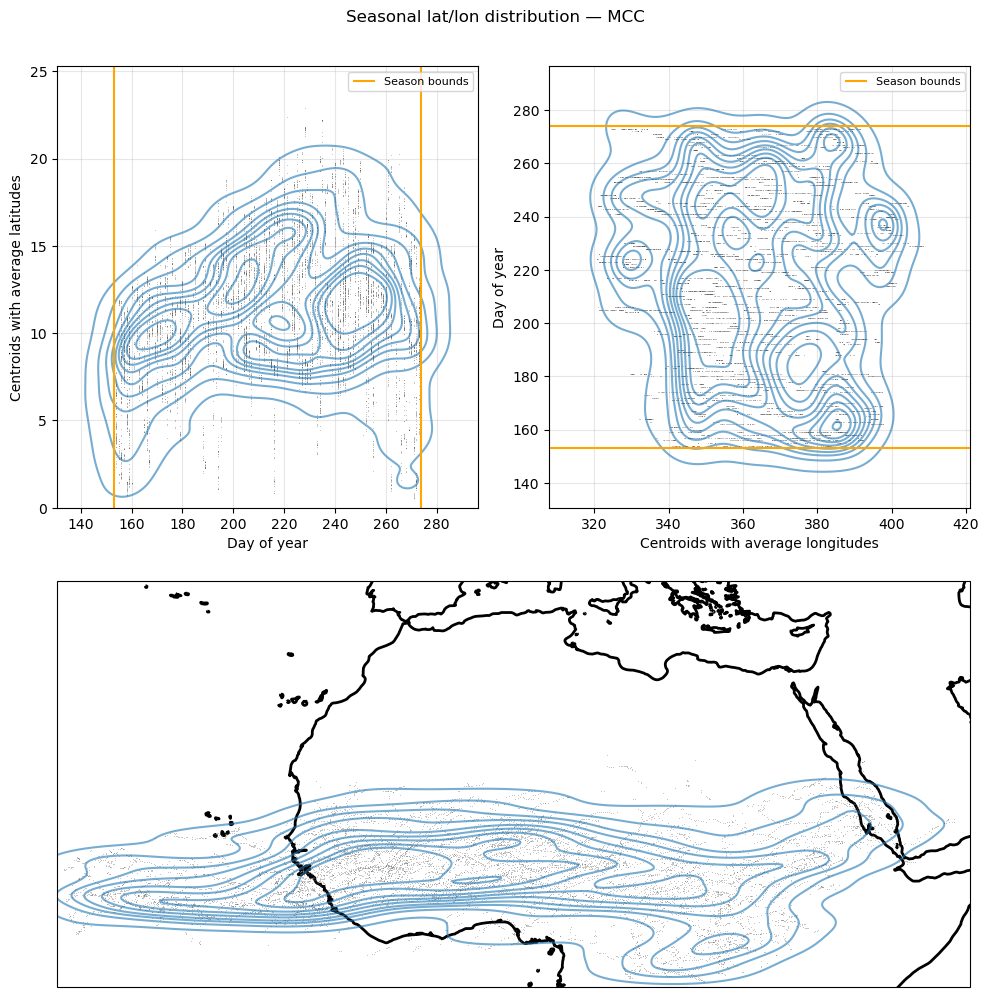

In [6]:
af2.seasonal_latlon(tbI, ce_claI_p, "MCC")

In [ ]:
print(len(ce_clasI))                  # number of CE rows
print(ce_clasI.mcs_id.nunique()) 